# 📰 The Headline Shift
### Measuring Ideology and Sentiment in U.S. Online News Headlines (2013–2022)
---
Run cells in order. Cells marked **⚡ Required** must be run; others are optional pipeline steps.

## ⚡ Step 1: Mount Google Drive & Unzip Project

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, zipfile

# ── CONFIG: update this path if your zip lives somewhere else in Drive ──
ZIP_PATH = '/content/drive/MyDrive/ML/Project/headline_shift_NEW.zip'
EXTRACT_DIR = '/content/headline_shift'
# ───────────────────────────────────────────────────────────────────────

assert os.path.exists(ZIP_PATH), f"Zip not found at {ZIP_PATH} — check the path above."

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
os.listdir(EXTRACT_DIR)

Extracted to: /content/headline_shift


['__MACOSX', 'headline_shift_NEW']

In [3]:
# Auto-detect the actual project root (handles nested folder inside zip)
import glob

candidates = glob.glob(f'{EXTRACT_DIR}/**/run_pipeline.py', recursive=True)
if not candidates:
    raise FileNotFoundError("Could not find run_pipeline.py — check zip structure.")

PROJECT_ROOT = os.path.dirname(candidates[0])
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)
print(os.listdir('.'))

Project root: /content/headline_shift/headline_shift_NEW
['models', 'outputs', 'notebooks', 'loss_curves.png', '.DS_Store', 'requirements.txt', 'README.md', '.streamlit', '.claude', 'app', '.gitignore', 'src', 'run_pipeline.py', 'data']


## ⚡ Step 2: Install Dependencies

In [4]:
!pip install -r requirements.txt -q

In [5]:
# Verify key imports
import torch, transformers, sklearn, streamlit, vaderSentiment
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())

torch: 2.10.0+cu128
transformers: 5.0.0
GPU available: True


## ⚡ Step 3: Prepare Data

### Access kagglehub API + process data


In [6]:
import os, json

# Paste your token string here
token = "KGAT_a4b5b259b9a10f86bec0544440f8a089"
username = "samdelong1221"  # ← fill this in

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

kaggle_json = {"username": username, "key": token}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_json, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ kaggle.json created!")

# verify it works
!kaggle datasets list

✅ kaggle.json created!
ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                           Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000           4620        119                1  
ssssws/chocolate-sales-dataset-2023-2024                        Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           8103        134                1  
grandmaster07/student-exam-performance-dataset-analysis         Student Exam Performance Dataset Analysis                96178  2026-02-10 09:47:13.350000          12443        

In [7]:
# Downloads and processes QBias and Kaggle datasets.
!python data/download_data.py

  Headline Shift – Data Download & Preparation
[1/3] Processing QBias data …
  ✓ Saved 21754 records → /content/headline_shift/headline_shift_NEW/data/processed/qbias_clean.csv

[2/3] Downloading Kaggle dataset …
  Already processed at /content/headline_shift/headline_shift_NEW/data/processed/headlines_filtered.csv, skipping.

[3/3] Data summary:
  QBias:     21754 rows | Labels: {'left': 10275, 'right': 7226, 'center': 4253}
  Headlines: 1068680 rows | Pubs: {'Washington Post': 360932, 'New York Times': 286278, 'Fox News': 272889, 'CNN': 148581}

✓ Done.


## Step 4: Run the Pipeline

In [10]:
# ── OPTION A: Full pipeline (baseline + transformer + inference + plots)
# Slow — transformer training can take 20–40 min on CPU; much faster on GPU.

!python run_pipeline.py --epochs 3

  The Headline Shift: Full Pipeline

▶ Step 1: Data Preparation
  Headline Shift – Data Download & Preparation
[1/3] Processing QBias data …
  ✓ Saved 21754 records → /content/headline_shift/headline_shift_NEW/data/processed/qbias_clean.csv

[2/3] Downloading Kaggle dataset …
  Already processed at /content/headline_shift/headline_shift_NEW/data/processed/headlines_filtered.csv, skipping.

[3/3] Data summary:
  QBias:     21754 rows | Labels: {'left': 10275, 'right': 7226, 'center': 4253}
  Headlines: 1068680 rows | Pubs: {'Washington Post': 360932, 'New York Times': 286278, 'Fox News': 272889, 'CNN': 148581}

✓ Done.

▶ Step 2: Loading & Splitting QBias Data
  QBias: 21754 samples
  Label distribution: {'left': 10275, 'right': 7226, 'center': 4253}
  Split: train=15227, val=3263, test=3264

▶ Step 3: Training Baseline Model (TF-IDF + Logistic Regression)

══ Baseline: TF-IDF + Logistic Regression ══
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: Future

In [ ]:
# ── OPTION B: Skip transformer training (fast, baseline only) ──
!python run_pipeline.py --skip-transformer

In [ ]:
# ── OPTION C: Data prep only ──
!python run_pipeline.py --data-only

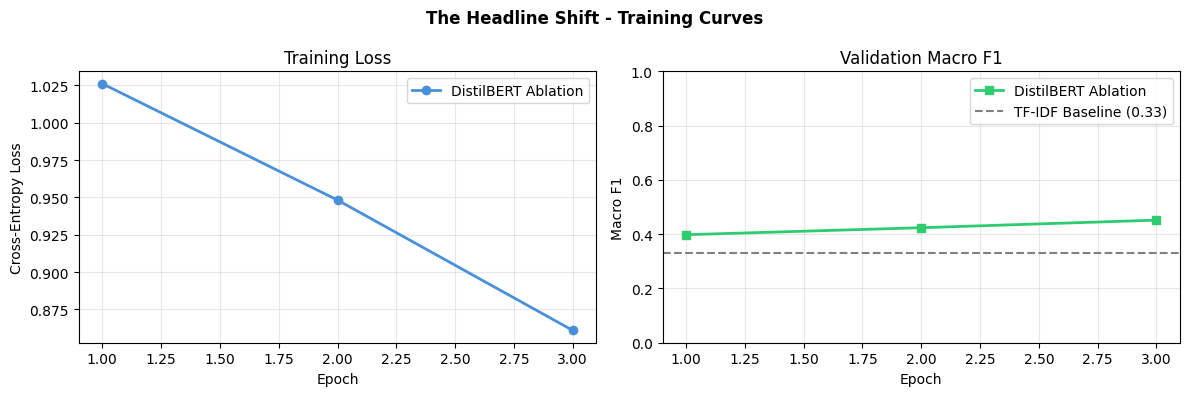

Saved: loss_curves.png


In [15]:
# VIEW LOSS CURVES

# Values from training output — we will need to add more rows as we run more epochs/revamp to save
import matplotlib.pyplot as plt

epochs     = [1, 2, 3]
train_loss = [1.0261, 0.9482, 0.8610]
train_acc  = [0.4709, 0.5433, 0.6029]
val_f1     = [0.3980, 0.4238, 0.4517]
baseline_f1 = 0.33

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, 'o-', color='#4a90d9', linewidth=2, label='DistilBERT Ablation')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, val_f1, 's-', color='#2ecc71', linewidth=2, label='DistilBERT Ablation')
axes[1].axhline(baseline_f1, linestyle='--', color='gray', label='TF-IDF Baseline (0.33)')
axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle('The Headline Shift - Training Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curves.png")

## Step 5: View Output Plots

Found 7 plots:
  outputs/plots/election_effect.png
  outputs/plots/emotionality_trends.png
  outputs/plots/ideology_by_topic.png
  outputs/plots/ideology_distribution_by_year.png
  outputs/plots/ideology_trends.png
  outputs/plots/sentiment_distribution.png
  outputs/plots/sentiment_trends.png


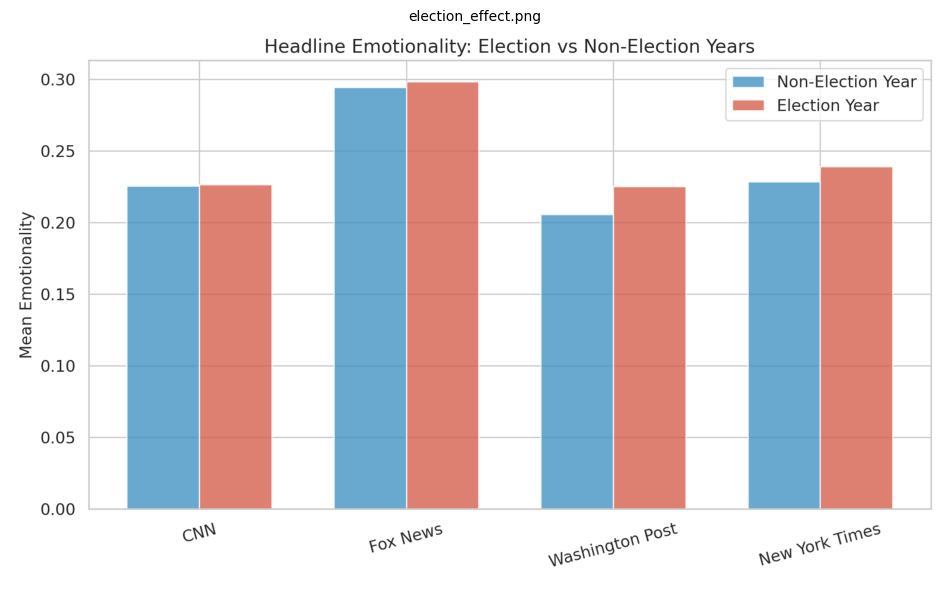

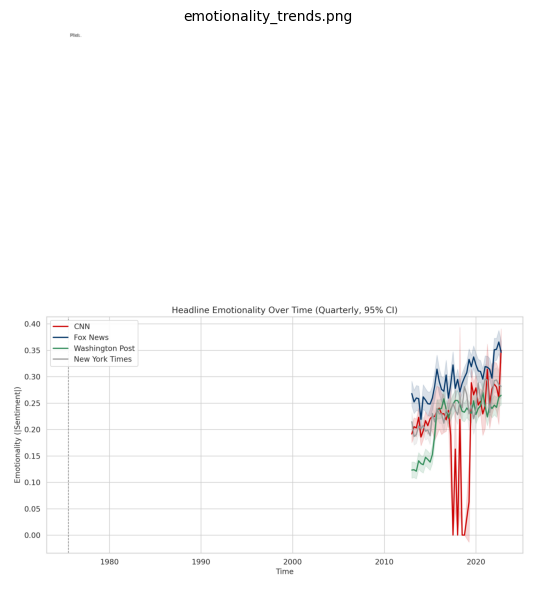

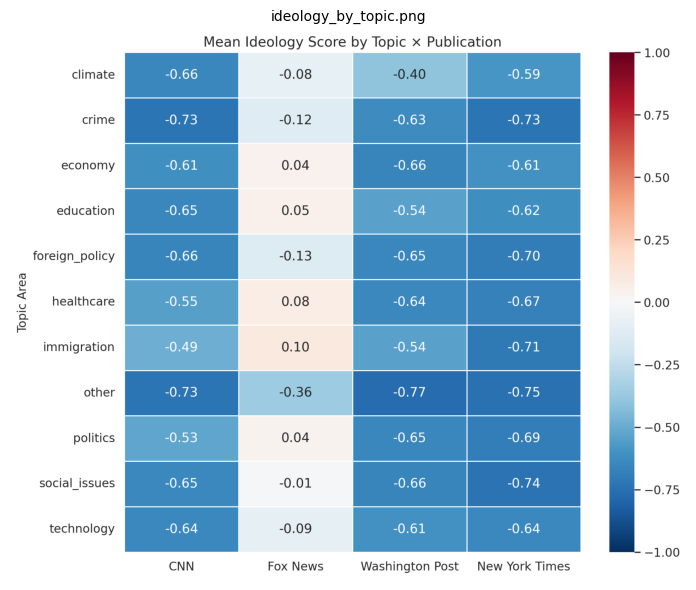

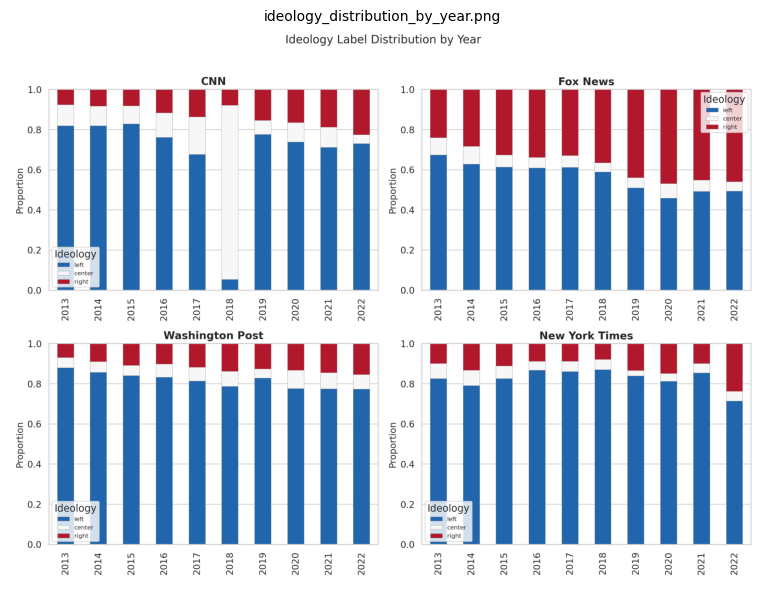

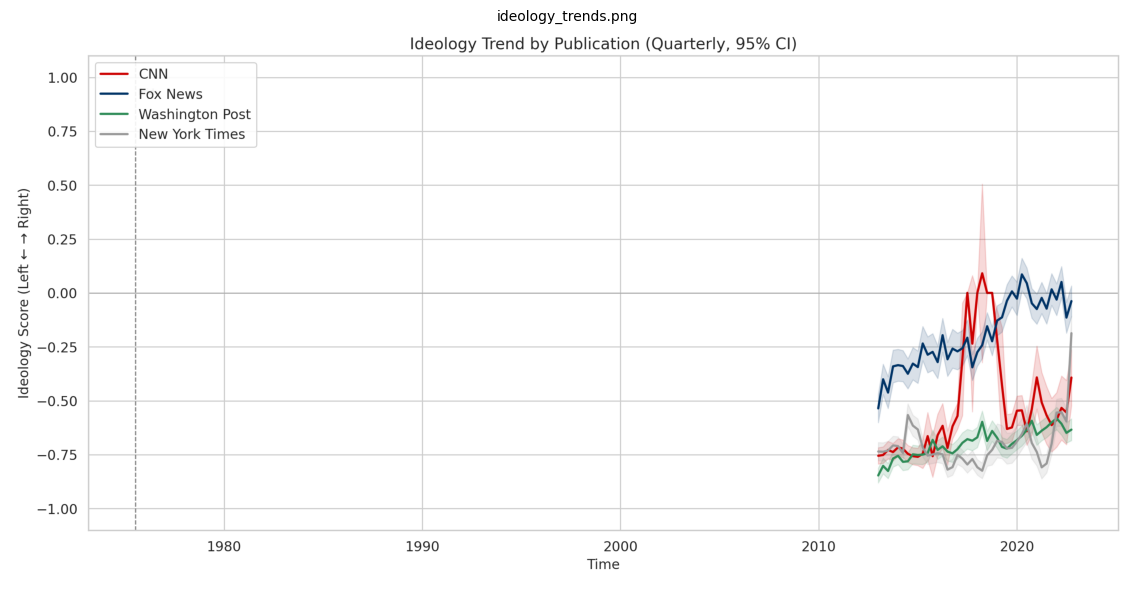

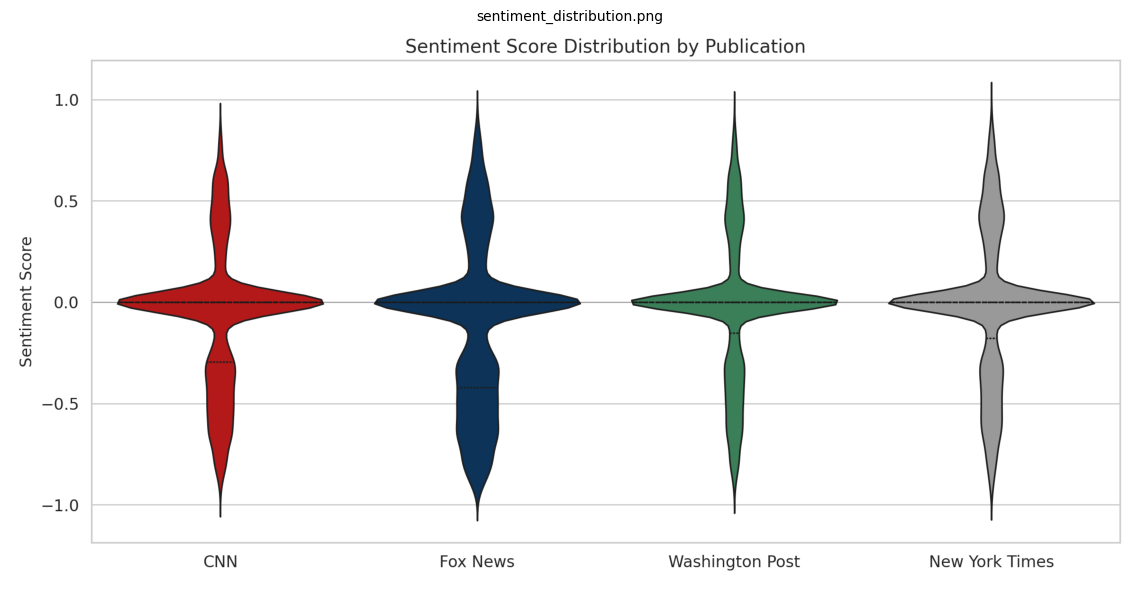

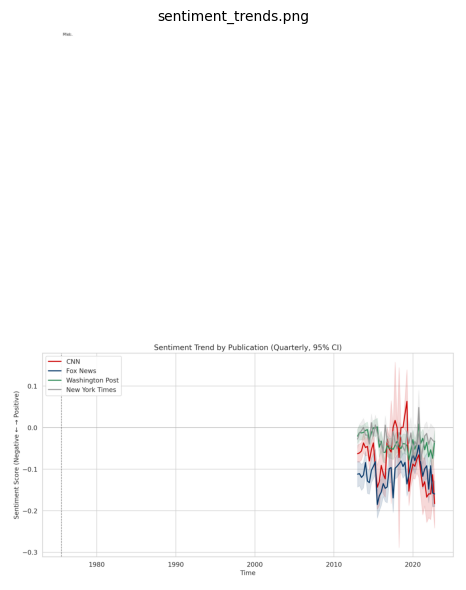

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

plot_files = sorted(glob.glob('outputs/plots/*.png'))
print(f"Found {len(plot_files)} plots:")
for p in plot_files:
    print(' ', p)

for path in plot_files:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(mpimg.imread(path))
    ax.axis('off')
    ax.set_title(os.path.basename(path), fontsize=10)
    plt.tight_layout()
    plt.show()

## Step 6: Active Learning App (Class Data Collection)
This launches the Streamlit app for in-class headline rating.
Run this cell and share the `ngrok` public URL with the class.

In [ ]:
import os

os.makedirs("/root/.streamlit", exist_ok=True)

with open("/root/.streamlit/secrets.toml", "w") as f:
    f.write("""
SUPABASE_URL = "https://qsattkpapafuuyegewmy.supabase.co"
SUPABASE_KEY = "sb_publishable_o2eiOycgBClg2W-UwX_wxQ_H-mGzF2N"
""")

print("✅ secrets.toml created")

In [ ]:
!pip install pyngrok -q
from pyngrok import ngrok
import threading, subprocess, time

# Kill any existing tunnels
ngrok.kill()

# add with token
ngrok.set_auth_token("3BdByqx4B5OmFedZEippM6cToPo_6BLG8XmLa8kPDuAvPW3Ad")

# Start Streamlit in the background
proc = subprocess.Popen(
    ['streamlit', 'run', 'app/active_learning_app.py',
     '--server.port=8501', '--server.headless=true'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(4)  # give streamlit a moment to start

# Open public tunnel
public_url = ngrok.connect(8501)
print("\n" + "="*50)
print("SHARE THIS URL WITH THE CLASS:")
print(public_url)
print("="*50)
print("\nKeep this cell running while collecting data.")
print("Data is saved to SQLite as ratings come in.")

In [ ]:
# ── Run this to stop the app and close the tunnel ──
proc.terminate()
ngrok.kill()
print("App stopped.")

## Step 7: Save Outputs Back to Drive

In [17]:
import shutil, datetime

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M')
dest = f'/content/drive/MyDrive/headline_shift_outputs_{timestamp}'

shutil.copytree('outputs', dest)
print(f"Outputs saved to Drive: {dest}")

Outputs saved to Drive: /content/drive/MyDrive/headline_shift_outputs_20260330_1243


In [21]:
import matplotlib.pyplot as plt
import shutil, datetime, os

# ── Generate and save loss curve to outputs folder ──
epochs     = [1, 2, 3]
train_loss = [1.0261, 0.9482, 0.8610]
val_f1     = [0.3980, 0.4238, 0.4517]
baseline_f1 = 0.33

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, 'o-', color='#4a90d9', linewidth=2, label='DistilBERT Ablation')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, val_f1, 's-', color='#2ecc71', linewidth=2, label='DistilBERT Ablation')
axes[1].axhline(baseline_f1, linestyle='--', color='gray', label='TF-IDF Baseline (0.33)')
axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle('The Headline Shift - Training Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/loss_curves.png', dpi=150, bbox_inches='tight')
plt.close()

# ── Copy everything to Drive ──
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M')
dest = f'/content/drive/MyDrive/headline_shift_outputs_{timestamp}'
shutil.copytree('outputs', dest)
print(f"Outputs saved to Drive: {dest}")

Outputs saved to Drive: /content/drive/MyDrive/headline_shift_outputs_20260330_1258


## (Optional) Interactive Analysis Notebook

In [ ]:
# Run the analysis notebook inline
!pip install nbconvert -q
!jupyter nbconvert --to notebook --execute notebooks/analysis.ipynb --output notebooks/analysis_executed.ipynb
print("Executed notebook saved to notebooks/analysis_executed.ipynb")